In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
df = pd.read_csv("energy_data.csv")
print(df.head())
print(df.columns)

             timestamp  fridge  ac  lights  microwave  total_power
0  2023-01-01 00:00:00     128   0      80        907         1115
1  2023-01-01 01:00:00      52   0      35          0           87
2  2023-01-01 02:00:00     105   0      52          0          157
3  2023-01-01 03:00:00     153   0       0          0          153
4  2023-01-01 04:00:00     113   0      62          0          175
Index(['timestamp', 'fridge', 'ac', 'lights', 'microwave', 'total_power'], dtype='str')


In [3]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp')
df = df.drop_duplicates()
df = df.drop_duplicates(subset='timestamp', keep='first')
df = df.set_index('timestamp')
df = df.ffill().bfill()

print("===== Data Cleaning Check =====")
print("Shape:", df.shape)
print("Missing values:\n", df.isnull().sum())
print("Duplicate timestamps:", df.index.duplicated().sum())
print("Is index sorted?:", df.index.is_monotonic_increasing)
print("Index type:", df.index.dtype)

df.head()

===== Data Cleaning Check =====
Shape: (4344, 5)
Missing values:
 fridge         0
ac             0
lights         0
microwave      0
total_power    0
dtype: int64
Duplicate timestamps: 0
Is index sorted?: True
Index type: datetime64[us]


,fridge,ac,lights,microwave,total_power
timestamp,,,,,
2023-01-01 00:00:00,128,0,80,907,1115
2023-01-01 01:00:00,52,0,35,0,87
2023-01-01 02:00:00,105,0,52,0,157
2023-01-01 03:00:00,153,0,0,0,153
2023-01-01 04:00:00,113,0,62,0,175


In [5]:
df_hourly = df.resample('h').mean()
df_hourly = df_hourly.ffill().bfill()

if 'total_power' not in df_hourly.columns:
    df_hourly['total_power'] = df_hourly.sum(axis=1)

print(df_hourly.head())
print(df_hourly.shape)

                     fridge   ac  lights  microwave  total_power
timestamp                                                       
2023-01-01 00:00:00   128.0  0.0    80.0      907.0       1115.0
2023-01-01 01:00:00    52.0  0.0    35.0        0.0         87.0
2023-01-01 02:00:00   105.0  0.0    52.0        0.0        157.0
2023-01-01 03:00:00   153.0  0.0     0.0        0.0        153.0
2023-01-01 04:00:00   113.0  0.0    62.0        0.0        175.0
(4344, 5)


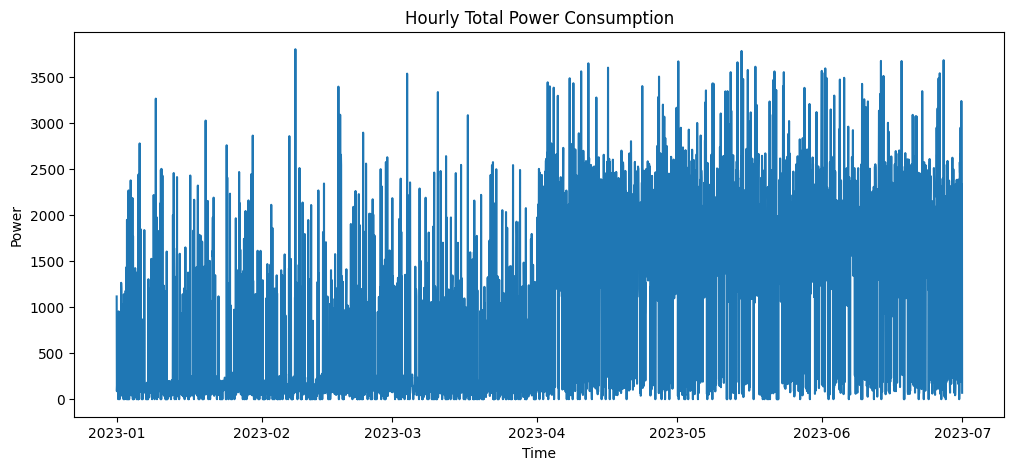

In [6]:
plt.figure(figsize=(12,5))
plt.plot(df_hourly.index, df_hourly['total_power'])
plt.title("Hourly Total Power Consumption")
plt.xlabel("Time")
plt.ylabel("Power")
plt.show()

In [7]:
df_feat = df_hourly.copy()

df_feat['hour'] = df_feat.index.hour
df_feat['day'] = df_feat.index.day
df_feat['month'] = df_feat.index.month
df_feat['day_of_week'] = df_feat.index.dayofweek

df_feat['lag_1'] = df_feat['total_power'].shift(1)
df_feat['lag_24'] = df_feat['total_power'].shift(24)

df_feat['rolling_mean_24'] = df_feat['total_power'].rolling(24).mean()
df_feat['rolling_std_24'] = df_feat['total_power'].rolling(24).std()

df_feat = df_feat.dropna()

print(df_feat.head())
print(df_feat.shape)

                     fridge      ac  lights  microwave  total_power  hour  \
timestamp                                                                   
2023-01-02 00:00:00     0.0  1162.0    39.0        0.0       1201.0     0   
2023-01-02 01:00:00   138.0     0.0    87.0        0.0        225.0     1   
2023-01-02 02:00:00     0.0     0.0    40.0        0.0         40.0     2   
2023-01-02 03:00:00   116.0     0.0    42.0        0.0        158.0     3   
2023-01-02 04:00:00    80.0     0.0    74.0        0.0        154.0     4   

                     day  month  day_of_week   lag_1  lag_24  rolling_mean_24  \
timestamp                                                                       
2023-01-02 00:00:00    2      1            0  1263.0  1115.0       257.541667   
2023-01-02 01:00:00    2      1            0  1201.0    87.0       263.291667   
2023-01-02 02:00:00    2      1            0   225.0   157.0       258.416667   
2023-01-02 03:00:00    2      1            0    40.0   

In [8]:
features = ['hour', 'day', 'month', 'day_of_week', 'lag_1', 'lag_24', 'rolling_mean_24', 'rolling_std_24']
target = 'total_power'

X = df_feat[features]
y = df_feat[target]

split_idx = int(len(df_feat) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (3456, 8)
X_test : (864, 8)
y_train: (3456,)
y_test : (864,)


In [10]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R2  :", r2_lr)

Linear Regression Performance
MAE : 668.9978649361335
RMSE: 846.1545767928491
R2  : 0.03280992725672194


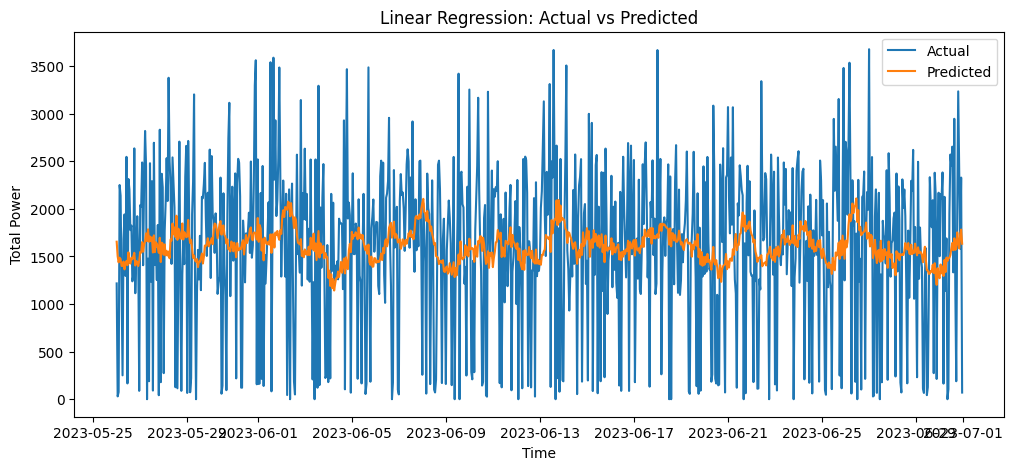

In [11]:
plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test.values, label='Actual')
plt.plot(y_test.index, y_pred_lr, label='Predicted')
plt.title("Linear Regression: Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Total Power")
plt.legend()
plt.show()

In [12]:
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': lr_model.coef_
}).sort_values(by='Coefficient', ascending=False)

print(coef_df)

           Feature  Coefficient
2            month     4.892472
6  rolling_mean_24     1.076624
0             hour     0.384155
5           lag_24    -0.016456
7   rolling_std_24    -0.043680
4            lag_1    -0.060585
1              day    -0.376796
3      day_of_week    -2.324803


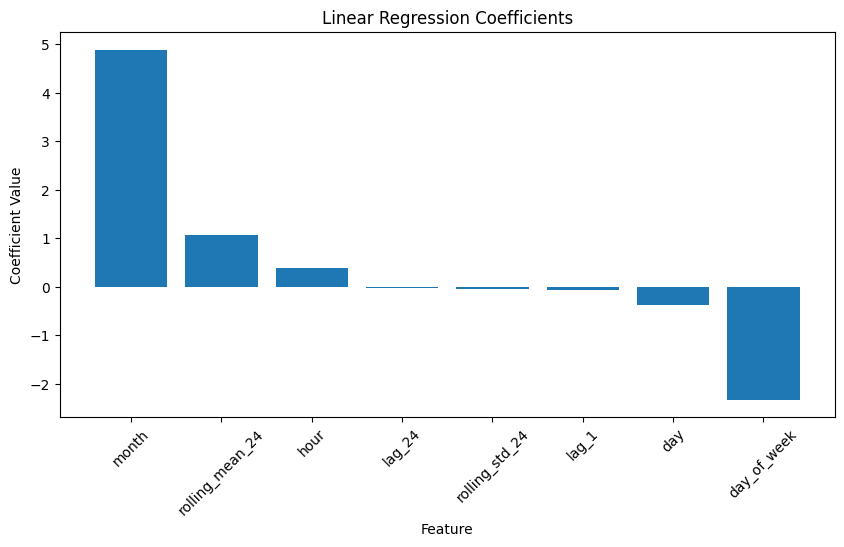

In [13]:
plt.figure(figsize=(10,5))
plt.bar(coef_df['Feature'], coef_df['Coefficient'])
plt.title("Linear Regression Coefficients")
plt.xlabel("Feature")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=45)
plt.show()

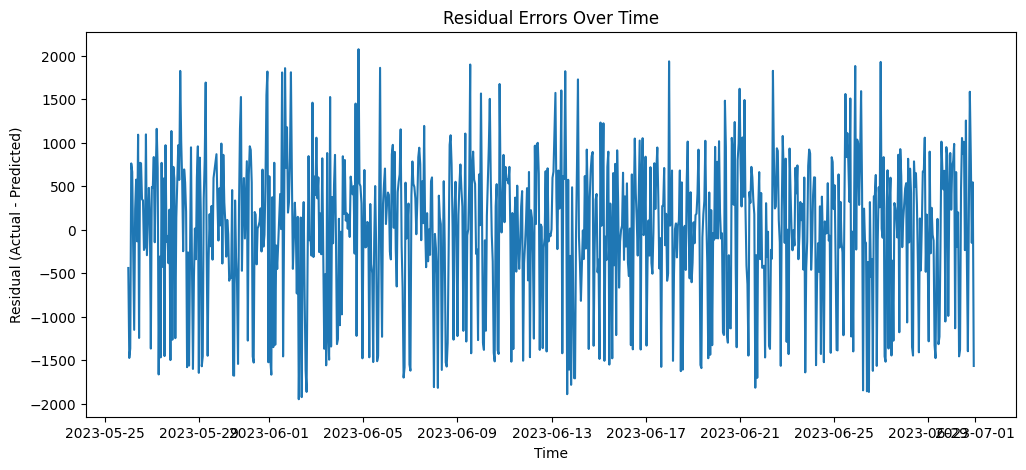

In [14]:
residuals = y_test - y_pred_lr

plt.figure(figsize=(12,5))
plt.plot(y_test.index, residuals)
plt.title("Residual Errors Over Time")
plt.xlabel("Time")
plt.ylabel("Residual (Actual - Predicted)")
plt.show()

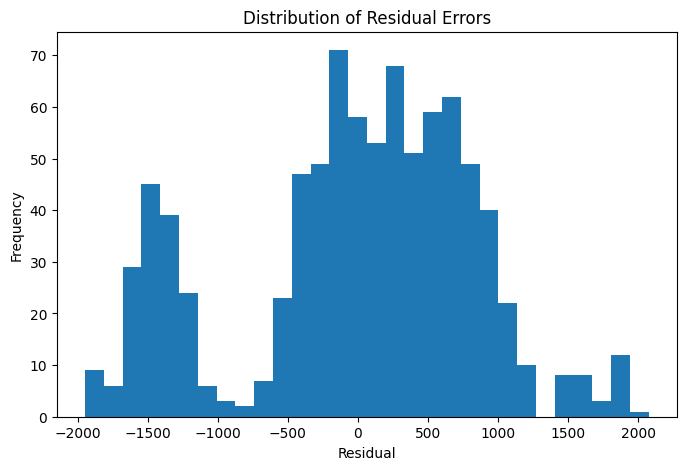

In [15]:
plt.figure(figsize=(8,5))
plt.hist(residuals, bins=30)
plt.title("Distribution of Residual Errors")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

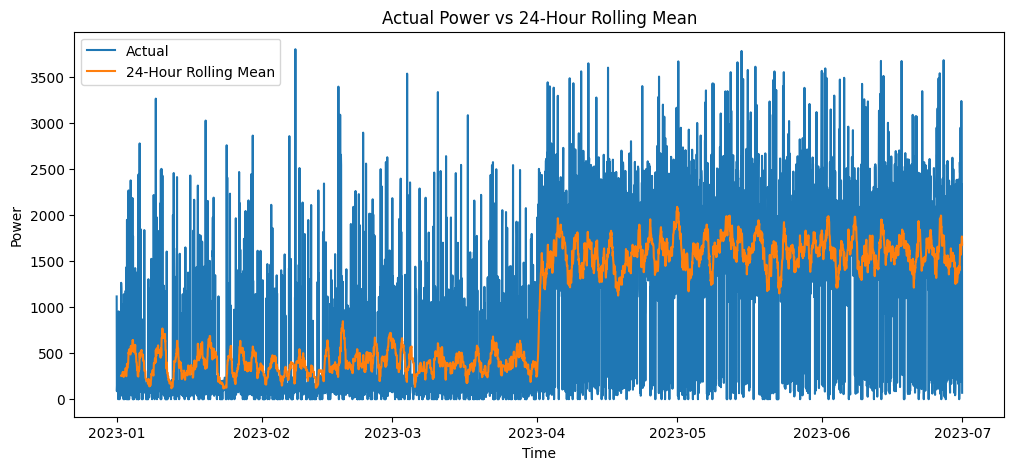

In [16]:
df_hourly['rolling_mean_24'] = df_hourly['total_power'].rolling(24).mean()

plt.figure(figsize=(12,5))
plt.plot(df_hourly.index, df_hourly['total_power'], label='Actual')
plt.plot(df_hourly.index, df_hourly['rolling_mean_24'], label='24-Hour Rolling Mean')
plt.title("Actual Power vs 24-Hour Rolling Mean")
plt.xlabel("Time")
plt.ylabel("Power")
plt.legend()
plt.show()

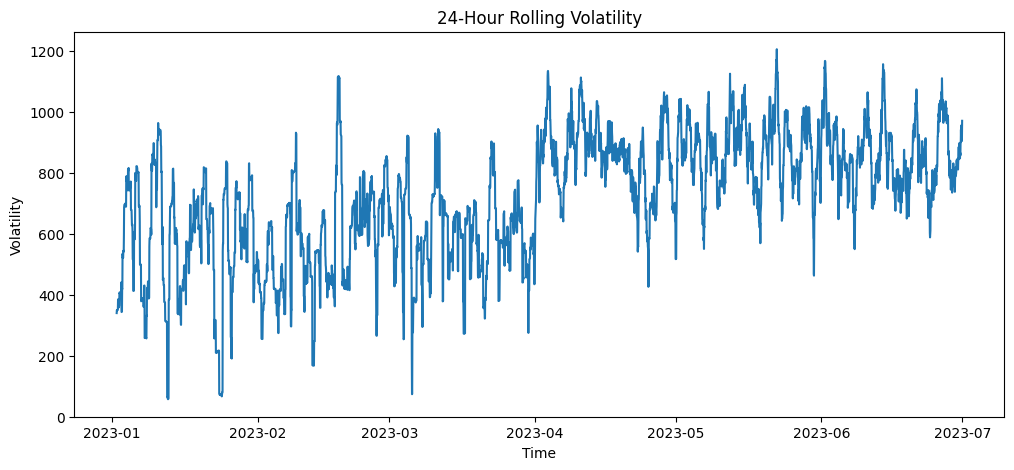

In [17]:
df_hourly['volatility_24'] = df_hourly['total_power'].rolling(24).std()

plt.figure(figsize=(12,5))
plt.plot(df_hourly.index, df_hourly['volatility_24'])
plt.title("24-Hour Rolling Volatility")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.show()

In [18]:
def shannon_entropy(series, bins=30):
    counts, _ = np.histogram(series, bins=bins)
    probs = counts / np.sum(counts)
    probs = probs[probs > 0]
    return -np.sum(probs * np.log2(probs))

entropy_val = shannon_entropy(df_hourly['total_power'].dropna())
print("Shannon Entropy:", entropy_val)

Shannon Entropy: 3.617832023405317


In [19]:
series = df_hourly['total_power'].dropna().values
N = len(series)
mean_series = np.mean(series)

Y = np.cumsum(series - mean_series)
R = np.max(Y) - np.min(Y)
S = np.std(series)

hurst = np.log(R / S) / np.log(N)
print("Hurst Exponent:", hurst)

Hurst Exponent: 0.8618574728687645


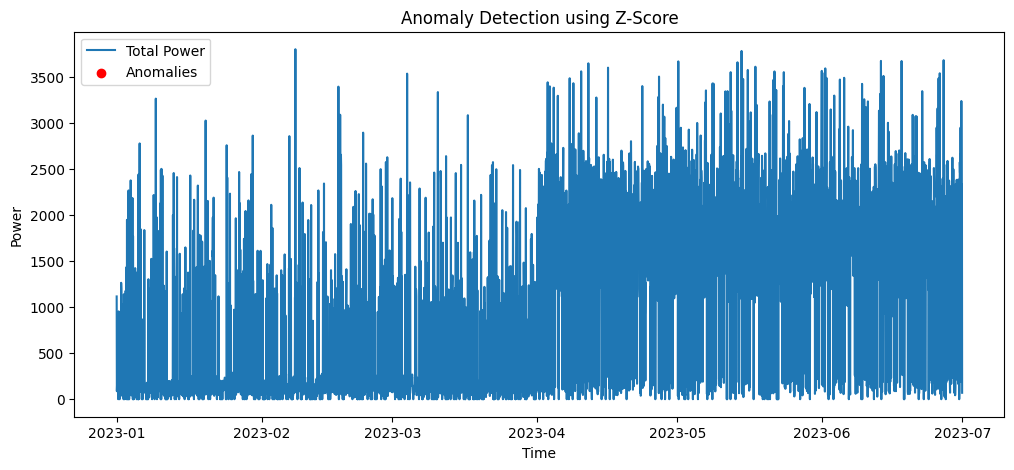

Number of anomalies: 0


In [20]:
z_scores = np.abs((df_hourly['total_power'] - df_hourly['total_power'].mean()) / df_hourly['total_power'].std())
anomalies = df_hourly[z_scores > 3]

plt.figure(figsize=(12,5))
plt.plot(df_hourly.index, df_hourly['total_power'], label='Total Power')
plt.scatter(anomalies.index, anomalies['total_power'], color='red', label='Anomalies')
plt.title("Anomaly Detection using Z-Score")
plt.xlabel("Time")
plt.ylabel("Power")
plt.legend()
plt.show()

print("Number of anomalies:", len(anomalies))

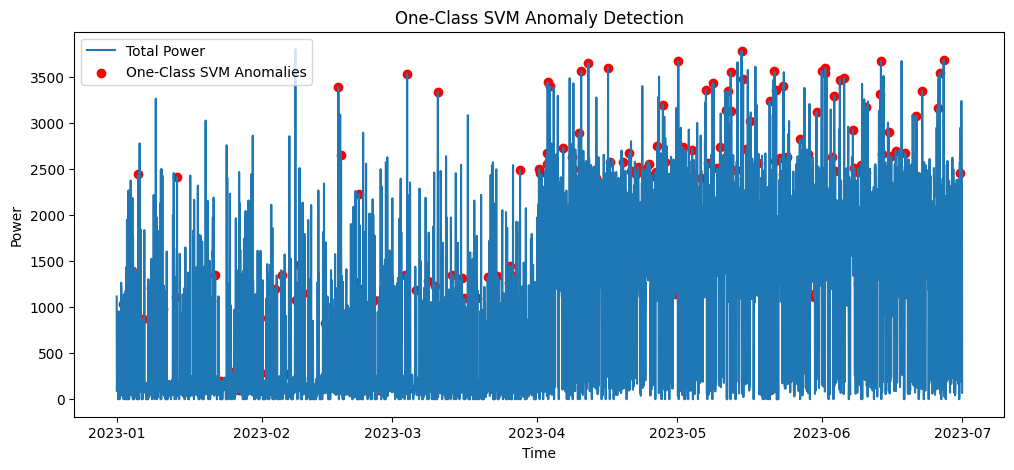

Number of One-Class SVM anomalies: 197


In [21]:
device_cols = ['fridge', 'ac', 'lights', 'microwave']

svm_data = df_hourly[device_cols].dropna().copy()

scaler = StandardScaler()
svm_scaled = scaler.fit_transform(svm_data)

ocsvm = OneClassSVM(kernel='rbf', gamma='auto', nu=0.05)
labels = ocsvm.fit_predict(svm_scaled)

svm_data['anomaly'] = labels
svm_anomalies = svm_data[svm_data['anomaly'] == -1]

plt.figure(figsize=(12,5))
plt.plot(df_hourly.loc[svm_data.index].index, df_hourly.loc[svm_data.index, 'total_power'], label='Total Power')
plt.scatter(svm_anomalies.index, df_hourly.loc[svm_anomalies.index, 'total_power'], color='red', label='One-Class SVM Anomalies')
plt.title("One-Class SVM Anomaly Detection")
plt.xlabel("Time")
plt.ylabel("Power")
plt.legend()
plt.show()

print("Number of One-Class SVM anomalies:", len(svm_anomalies))